In [ ]:
## plots saved to workspace folder

In [1]:
from dustysn.model import calc_model_flux
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np
from dustysn.model import full_model
from dustysn.model import import_data, fit_dust_model


100 100


/Users/sophiakressy/dustysn/dustysn/model.py:236: FutureWarning: Passing 'z' as keyword is deprecated since version 7.0 and will stop working in a future release. Pass it positionally to suppress this warning.
  distance = calc_distance(redshift)


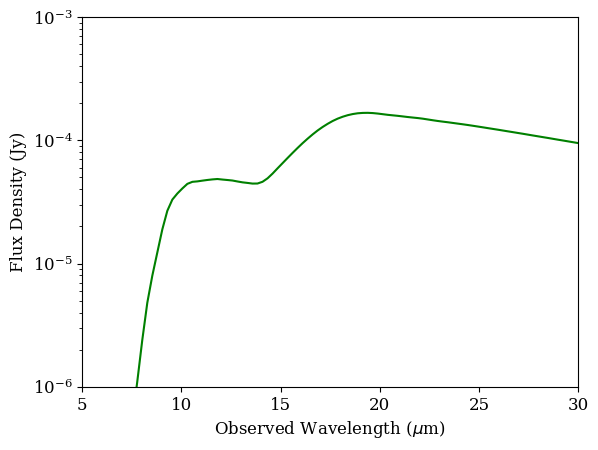

In [2]:
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'serif'})

# Basic parameters
dust_mass = 0.0008  # Solar masses
temperature = 158  # Kelvin
redshift = 0.001605
composition = 'silicate'  # 'carbon' or 'silicate'
grain_size = 0.1  # microns

# Wavelength grid (in microns)
obs_wave = np.linspace(5, 30, 100) * u.micron

# Calculate the model flux
model_flux = calc_model_flux(obs_wave, dust_mass, temperature, redshift,
                            grain_size=grain_size, composition=composition)

# Plot the model
print(len(obs_wave),len(model_flux))
plt.plot(obs_wave, model_flux, 'g')
plt.xlabel(r'Observed Wavelength ($\mu$m)')
plt.ylabel('Flux Density (Jy)')
plt.yscale('log')
plt.ylim(1e-6, 1e-3)
plt.xlim(5, 30)
plt.show()

# SN1983V

In [ ]:
# Define the parameters of the model
filename = './83V_photometry_table.txt'
object_name = 'SN1983V'
redshift = 0.0054
grain_size = 0.1 # Grain size in microns
n_components = 2 # Number of dust components to fit (1 or 2)

# Define the parameters of the fit
n_steps = 1000 # Number of steps in the MCMC fit
n_walkers = 200 # Number of walkers in the MCMC fit
n_cores = 6 # Number of parallel cores to use for the fit
sigma_clip = 2 # Sigma clipping to remove outliers
repeats = 2 # Number of times to repeat the fit

# Import data
obs_wave, obs_flux, obs_flux_err, obs_limits, obs_filters, obs_wave_filters, obs_trans_filters = import_data(filename)



### Run MCMC for a 2 component dust model

In [6]:
results, last_samples = fit_dust_model(obs_wave, obs_flux, obs_flux_err, obs_limits, redshift, object_name, composition_hot='silicate',composition_cold='carbon',
                                       grain_size=grain_size, n_components=n_components, n_walkers=n_walkers, n_steps=n_steps, n_cores=n_cores, sigma_clip=sigma_clip, repeats=repeats,
                                       obs_wave_filters=obs_wave_filters, obs_trans_filters=obs_trans_filters, plot=True, plots_trace=True,
                                       output_dir='.', add_sigma=True, distance = 18*u.Mpc)

Running MCMC with parallel processing using 6 cores...


100%|██████████| 1000/1000 [01:25<00:00, 11.67it/s]


Starting MCMC run 2 of 2...
Found 35 walkers outside 2-sigma range.
Replacing with new walkers drawn from within the clipped distribution...


100%|██████████| 1000/1000 [01:37<00:00, 10.24it/s]


Plotting Model...
Plotting Corner...
Plotting log_dust_mass_cold Trace...
Plotting temp_cold Trace...
Plotting log_dust_mass_hot Trace...
Plotting temp_hot Trace...
Plotting sigma Trace...
